## XSPEC / PyXspec 

`XSPEC` is a widely used tool in high-energy astrophysics for spectral fitting of X-ray data. By using `pyXspec`, you're enabling `XSPEC` functionality from Python, making it easier to automate the analysis. 

+ [Xspec](https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual//XspecManual.html)  
+ [PyXspec](https://heasarc.gsfc.nasa.gov/xanadu/xspec/python/html/index.html)

### 1.1 Module Imports 
+ `xspec`: Python interface to the XSPEC spectral fitting software.
+ `matplotlib`: Plotting library for the Python.

In [1]:
import os 
import sys
import glob
import shutil
import numpy as np
import pandas as pd
from xspec import *
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogLocator

### 1.2 Logging and Verbosity Settings

`Xset.chatter` and `Xset.logChatter`: These control the verbosity of XSPEC outputs. Values range from 0 (silent) to 25 (very detailed).  
`Xset.openLog("xspec.log"): Redirects XSPEC output to a log file, useful for debugging and keeping a record of your session.

In [2]:
ch = Xset.chatter
Xset.chatter = 20
lch = Xset.logChatter
Xset.logChatter = 20
logFile = Xset.openLog("xspec.log")
logFile = Xset.log

Logging to file: xspec.log


### 1.3 Load Spectral Data
+ `spec.pi`: This is the Pulse Height Amplitude (PHA) file containing the observed X-ray spectrum. It records the number of detected photons in each energy channel and represents the raw data collected by the X-ray telescope. This file is the basis for all spectral analysis.

+ `swxpc0to12s6_20130101v014.rmf`: This is the Response Matrix File (RMF) specific to the SWIFT XRT instrument. It defines how photons of different energies are distributed across the detector’s channels due to the instrument’s energy resolution. The RMF is crucial for accurately interpreting the observed spectrum by modeling the instrument’s response.

+ `spec.arf`: The Ancillary Response File (ARF) provides the telescope’s effective collecting area as a function of photon energy. It accounts for the instrument’s efficiency in detecting photons at different energies, including factors like mirror reflectivity and detector sensitivity. The ARF is necessary to convert theoretical photon fluxes into expected detector counts.

+ `spec_bkg.pi`: This background spectrum file contains counts from various background sources, such as cosmic background radiation or instrumental noise. Including the background spectrum is important to separate the source signal from unwanted background noise during analysis.

In [3]:
specdir = "00035905082_SPEC"

s1 = Spectrum(f"{specdir}/spec.pi")
s1.response = f"{specdir}/swxpc0to12s6_20130101v014.rmf"
s1.response.arf = f"{specdir}/spec.arf"
s1.background = f"{specdir}/spec_bkg.pi"


1 spectrum  in use
 
Spectral Data File: 00035905082_SPEC/spec.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  3.066e-01 +/- 1.722e-02
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-619
  Telescope: SWIFT Instrument: XRT  Channel Type: PI
  Exposure Time: 1034 sec
 Using fit statistic: chi
 No response loaded.
 Grouping data :
   1024 channels grouped to 619
        1 ******************************+-++-+++++++++++++++
       51 +++++++-+++++++++++--+-++++-+++++-+++++++++++++-++
      101 +++--+++++++++-+-+++++++-+-+++--+-+++-++-++-+-++--
      151 -++-+--+++--++-++-++-+-+--+--+++---+-+++-++-+++---
      201 ------------++--+---------+++--------+---+-+------
      251 --+----+-+++---------++----+------------+---------
      301 +----+--+-----+----+----------------+---+----++---
      351 ------+---------+--+--+---------------------------
      401 ---------+--------+------+-----------+---+--------
      451 +-------------------------------------------------
   

### 1.4 Ignore Energy Ranges
You typically ignore energy ranges outside the instrument's reliable response or where calibration is poor. For Swift-XRT, 0.3–10 keV is a standard "good" energy range for spectral fitting.

+ `AllData.ignore("bad")`: Ignores all data flagged as bad (e.g., non-physical or unreliable channels).
+ `s1.ignore("**-0.3,10.0-**")`: Ignores energy ranges below 0.3 keV and above 10.0 keV.

In [4]:
AllData.ignore("bad")
s1.ignore("**-0.3,10.0-**")


ignore:   456 channels ignored from  source number 1
    30 channels (1-30) ignored in spectrum #     1
    25 channels (595-619) ignored in spectrum #     1



### 1.5 Define Spectral Model

In this step, we define the physical model that we believe best describes the X-ray emission from our source. This model will be fit to the observed data to estimate key physical parameters and gain insight into the source’s properties.

Model: `tbabs*powerlaw`  
+ `tbabs`: The `tbabs` component models how X-rays are absorbed by gas and dust as they travel through space, primarily due to hydrogen atoms in the interstellar medium. This absorption affects mainly the low-energy part of the X-ray spectrum by reducing the number of photons detected. Without accounting for this absorption, our estimates of the intrinsic source emission would be inaccurate.
    + Parameter `nH`: This represents the hydrogen column density, measured in units of $10^{22}$ atoms per $cm^2$. Physically, it quantifies the number of hydrogen atoms along the line of sight between the observer and the source. A higher `nH` value means more absorption and thus a stronger suppression of low-energy X-rays. we calculate `nH` using tools like HEASARC’s [nH calculator](https://heasarc.gsfc.nasa.gov/cgi-bin/Tools/w3nh/w3nh.pl).
+ `powerlaw`: The power-law model is widely used to describe X-ray emission from sources where the photons originate from energetic processes, rather than thermal emission from hot gas. These processes include synchrotron radiation and inverse Compton scattering, which produce a continuum spectrum described by a power-law.

In [5]:
m1 = Model("tbabs*powerlaw")
m1.TBabs.nH = 0.0237
m1.TBabs.nH.frozen = True
m1.powerlaw.PhoIndex = 1.0


Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   3    2   powerlaw   norm                1.00000      +/-  0.0          
________________________________________________________________________

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.

Fit statistic  : Chi-Squared              2.796778e+08     using 163 bins.

### 1.6 Fit Configuration
We now configure how XSPEC will perform the model fitting to our observed X-ray data. Fitting the model means adjusting parameters to best match the observed data using a statistical method. 

When fitting a model to observational data, we need a way to measure how well the model describes the data. This is where statistical methods come into play. Chi-squared ($\chi^2$) is a statistical measure that quantifies the difference between the observed data points and the values predicted by the model, while taking into account the uncertainties (errors) in the measurements. The fitting algorithm tries to adjust the model parameters to minimize the total chi-squared value. The best fit is the set of parameters that produce the smallest chi-squared, meaning the model most closely matches the data within the expected error margins.

In [6]:
Fit.statMethod = "chi"
Fit.nIterations = 100
Fit.query = 'yes'
Fit.perform()

Default fit statistic is set to: Chi-Squared
   This will apply to all current and newly loaded spectra.

Fit statistic  : Chi-Squared              4.137115e+08     using 163 bins.

Test statistic : Chi-Squared              4.137115e+08     using 163 bins.
 Null hypothesis probability of 0.000000e+00 with 161 degrees of freedom
 Current data and model not fit yet.
Number of trials and critical delta: 100  0.01
                                   Parameters
Chi-Squared  |beta|/N    Lvl    2:PhoIndex        3:norm
121.895      20.7458      -3       2.86941    0.00137670
109.701      849.761      -4       2.36120    0.00163036
109.014      2440.62      -5       2.42898    0.00157122
109.014      60.6292      -6       2.43025    0.00156962
 Variances and Principal Axes
                 2        3  
 1.2789E-08|  0.0000   1.0000  
 1.3011E-02|  1.0000  -0.0000  
------------------------------

  Covariance Matrix
        1           2   
   1.301e-02  -5.357e-07
  -5.357e-07   1.281e-08
----

In [7]:
Fit.show()


Fit statistic  : Chi-Squared                  109.01     using 163 bins.

Test statistic : Chi-Squared                  109.01     using 163 bins.
 Null hypothesis probability of 9.99e-01 with 161 degrees of freedom


### 1.7 Evaluate Fit Quality
After fitting the model, we assess how well it describes the observed data by looking at statistical measures.

+ `Fit.statistic` gives the chi-squared value, which measures the overall difference between the observed data and the model prediction. Lower values mean a better fit.
+ `Fit.dof` returns the degrees of freedom, which is the number of independent data points minus the number of free parameters being fitted.
+ Dividing the chi-squared by the degrees of freedom gives the `reduced chi-squared` ($\chi_{red}^2$). This statistic helps us judge the goodness of fit relative to the model complexity.

A reduced chi-squared value near 1 indicates a good fit, where the model explains the data within the expected uncertainties. Values much larger than 1 suggest the model doesn’t fit well or errors are underestimated, while values much smaller than 1 might mean overfitting or overestimated errors.

In [8]:
chi = Fit.statistic
dof = Fit.dof
chi2red = Fit.testStatistic/dof

print(f"chi2red = {round(chi2red, 2)}")

chi2red = 0.68


### 1.8 Calculate Model Flux

In this step, we calculate the total flux of the fitted model within the energy range 0.3 to 10.0 keV, including estimates of the uncertainty.

In [9]:
AllModels.calcFlux("0.3 10.0 err")

Number of realizations used:  100
Confidence level (percent):  68
Parameter distribution is derived from fit covariance matrix.
 Model Flux 0.0048024 photons (6.7434e-12 ergs/cm^2/s) range (0.30000 - 10.000 keV)
     Error range  0.004535 - 0.005247    (6.383e-12 - 7.267e-12)  (68.00% confidence)


### 1.9 Configure Plotting
In this section, we set up how the spectral data and fit results will be visualized.

+ `Plot.device = "plot.ps"`: This directs XSPEC to save the plot output as a PostScript file.
+ `Plot.xAxis = "Hz"`: Sets the x-axis units to frequency (Hertz) instead of energy. This is useful depending on the scientific context or preference for viewing the data.
+ `Plot.xLog = True` and `Plot.yLog = True`: Apply logarithmic scaling to both axes. Log scales are essential in X-ray astronomy because source spectra and fluxes span many orders of magnitude in energy and intensity, making features easier to see and interpret.
+ `Plot.setRebin(20, 20)`: Rebins (groups) the data channels to reduce noise and improve visual clarity. Here, 20 channels are combined both in the data and the model, smoothing the plot without losing important spectral features.
`Plot("eeufspec", "ratio")`: Generates two key plots:
    + `eeufspec`: The unfolded energy spectrum multiplied by energy squared, which highlights spectral features by compensating for the steepness of the power-law spectrum.
    + `ratio`: The ratio of data to model, helping identify where the model fits well or deviates from the data, revealing residuals or systematic discrepancies.

In [10]:
Plot.device = f"plot.ps"
Plot.xAxis = "Hz"
Plot.xLog = True
Plot.yLog = True
Plot.setRebin(20, 20)
Plot("eeufspec","ratio")

### 1.10 Extract Spectrum Data
In this part, we take the spectral data and model results from XSPEC’s plotting system and save them into standard CSV files.

In [11]:
Plot.device = "/null"

Plot("eeufspec")
xVals = Plot.x()
yVals = Plot.y()
modVals = Plot.model()
yErrs = Plot.yErr()
dataM = np.column_stack((xVals, yVals, yErrs, modVals))
np.savetxt("spec.csv", dataM, delimiter=",", header="xVals,yVals,yErrs,modVals", comments="")

Plot("ratio")
xVals = Plot.x()
yVals = Plot.y()
yErrs = Plot.yErr()
dataR = np.column_stack((xVals, yVals, yErrs))
np.savetxt("ratio.csv", dataR, delimiter=",", header="xVals,yVals,yErrs", comments="")

### 1.11 Cleanup
At the end of the analysis, we clear the loaded data and close the log file to properly finalize the XSPEC session.

In [12]:
AllData.clear()
Xset.closeLog()

Log file closed.


In [15]:
for file in glob.glob("*csv"):
    shutil.move(file, specdir)

shutil.move("xspec.log", specdir)
shutil.move("plot.ps", specdir)

'00035905082_SPEC/plot.ps'

### 2. Plot Spectrum
In this step, we load the spectral data and model predictions saved earlier in a CSV file, and then use Python’s matplotlib library to create a detailed plot of the spectrum.

In [16]:
scsv = os.path.join(specdir, "spec.csv")
df_spect = pd.read_csv(scsv)
x1, y1, y1e, mdl = df_spect["xVals"], df_spect["yVals"], df_spect["yErrs"], df_spect["modVals"]

rcsv = os.path.join(specdir, "ratio.csv")
df_ratio = pd.read_csv(rcsv)
x2, y2, y2e = df_ratio["xVals"], df_ratio["yVals"], df_ratio["yErrs"]

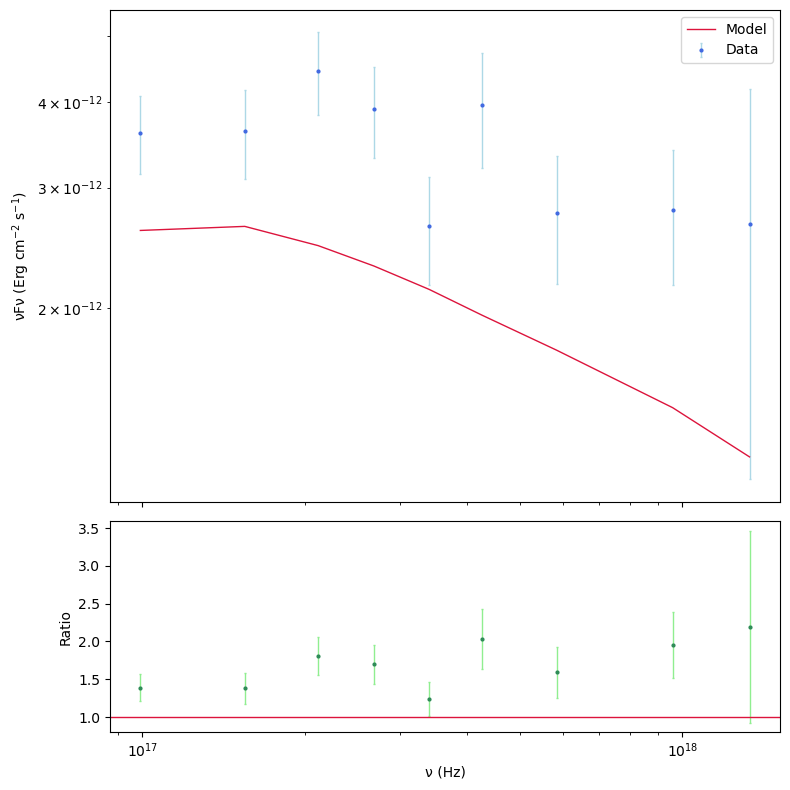

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [7, 3]}, sharex=True)

ax1.errorbar(x1, y1, yerr=y1e, fmt="o", markersize=2, label="Data", color="royalblue", ecolor="lightblue", elinewidth=1, capsize=1)
ax1.plot(x1, mdl, label="Model", color="crimson", linestyle="-", linewidth=1)
ax1.legend()
ax1.set_yscale("log")
ax1.set_ylabel(r'νFν (Erg cm$^{-2}$ s$^{-1}$)', fontsize=10)

ax2.errorbar(x2, y2, yerr=y2e, fmt="o", markersize=2, color="seagreen", ecolor="lightgreen", elinewidth=1, capsize=1)
ax2.axhline(1.0, color="crimson", linestyle="-", linewidth=1)
ax2.set_xlabel(r'ν (Hz)', fontsize=10)
ax2.set_ylabel('Ratio', fontsize=10)
ax2.set_xscale("log")

plt.subplots_adjust(hspace=0.1)
plt.tight_layout()
plt.savefig(f"{specdir}/spec.png", dpi=300, bbox_inches="tight")
plt.show()

Build Swift-XRT products: https://www.swift.ac.uk/user_objects/index.php